<a href="https://colab.research.google.com/github/niktes03/CS273-Final-Project/blob/main/Demo_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torchmetrics

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import gdown

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
EMOTION_EMOJIS = ['😠', '🤢', '😨', '😊', '😢', '😲', '😐']
COLORS = ['#e74c3c','#2ecc71','#9b59b6','#f39c12','#3498db','#1abc9c','#95a5a6']

print('✅ Imports done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.5 MB/s eta 0:00:00
Using device: cpu
✅ Imports done!


In [ ]:
# Auto-download and load the trained model
def build_model():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, 7)
    )
    return model

# Download model weights from Google Drive
FILE_ID = '17cHLFeNLVc85eE8E6jF39ETqzyzcc6yP'
gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', 'best_model.pth', quiet=False)

model = build_model()
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model = model.to(device)
model.eval()

print('✅ Model loaded successfully!')

Downloading...
From: https://drive.google.com/uc?id=17cHLFeNLVc85eE8E6jF39ETqzyzcc6yP
To: /content/best_model.pth
100%|██████████| 17.6M/17.6M [00:00<00:00, 55.1MB/s]


✅ Model loaded successfully!


Upload a face image:


Saving Photo on 12-14-25 at 2.45 PM.jpg to Photo on 12-14-25 at 2.45 PM.jpg


/tmp/ipykernel_343/1137611724.py:42: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


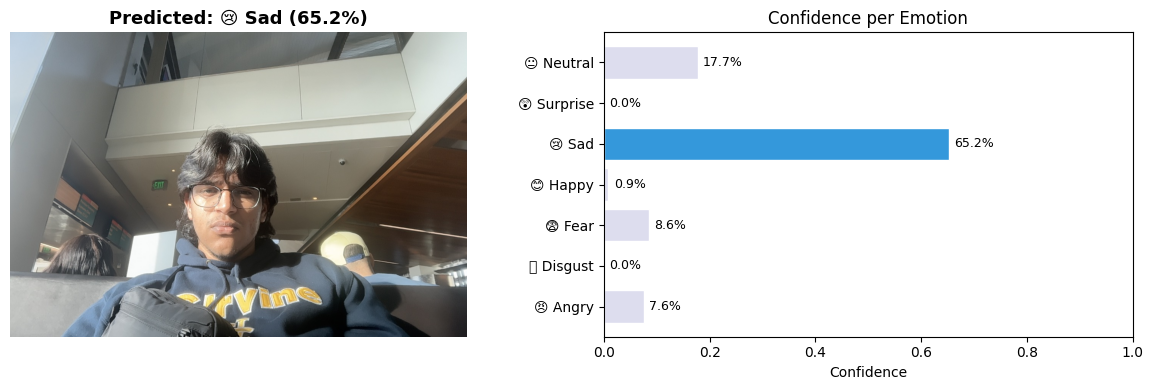


Result: 😢 Sad — 65.2% confidence


In [ ]:
# Upload a face image and predict
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_emotion(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    predicted_idx = probs.argmax()
    predicted_emotion = EMOTION_LABELS[predicted_idx]
    predicted_emoji   = EMOTION_EMOJIS[predicted_idx]
    confidence = probs[predicted_idx]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(
        f'Predicted: {predicted_emoji} {predicted_emotion.capitalize()} ({confidence:.1%})',
        fontsize=13, fontweight='bold'
    )

    bar_colors = [COLORS[i] if i == predicted_idx else '#dde' for i in range(7)]
    labels_with_emoji = [f'{e} {l.capitalize()}' for e, l in zip(EMOTION_EMOJIS, EMOTION_LABELS)]
    axes[1].barh(labels_with_emoji, probs, color=bar_colors, edgecolor='white')
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Confidence per Emotion', fontsize=12)
    axes[1].set_xlim(0, 1)
    for i, p in enumerate(probs):
        axes[1].text(p + 0.01, i, f'{p:.1%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'\nResult: {predicted_emoji} {predicted_emotion.capitalize()} — {confidence:.1%} confidence')


print('Upload a face image:')
uploaded = files.upload()
image_name = list(uploaded.keys())[0]
predict_emotion(image_name)

Upload another face image:


Saving smile.avif to smile (1).avif


/tmp/ipykernel_343/1137611724.py:42: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


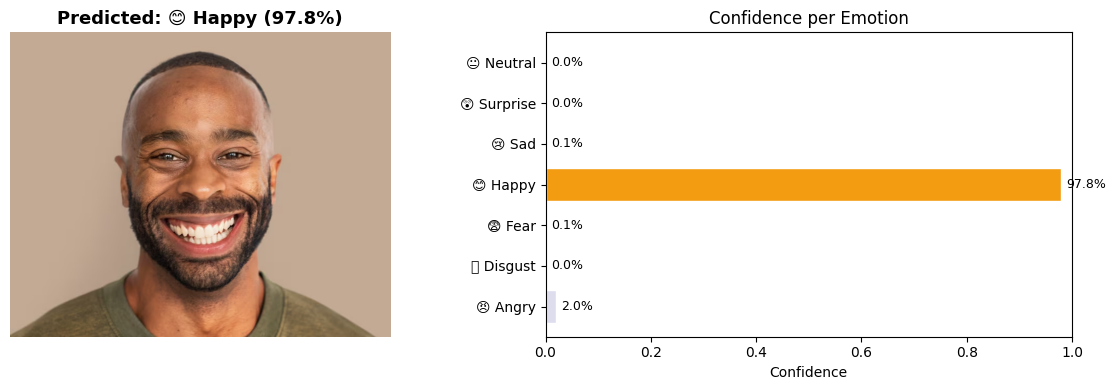


Result: 😊 Happy — 97.8% confidence


In [ ]:
# Run again on a different image
print('Upload another face image:')
uploaded = files.upload()
image_name = list(uploaded.keys())[0]
predict_emotion(image_name)